In [1]:
print("Hello")

Hello


In [7]:
import pandas as pd
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [9]:
import pandas as pd 

housing = pd.read_csv("housing.csv")
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,-122.246000,37.850000,46.800000,2500.900000,470.100000,976.300000,458.200000,4.996080,314480.000000
std,0.012649,0.012472,10.064238,1858.210456,315.910483,648.036702,323.469662,2.243359,68355.310287
min,-122.260000,37.840000,21.000000,880.000000,129.000000,322.000000,126.000000,2.080400,226700.000000
25%,-122.250000,37.840000,44.500000,1322.250000,218.500000,511.500000,199.500000,3.667125,263250.000000
50%,-122.250000,37.850000,52.000000,2081.000000,384.500000,829.500000,386.500000,3.941500,320250.000000
75%,-122.242500,37.850000,52.000000,2966.750000,681.500000,1193.750000,634.000000,6.853825,349625.000000
max,-122.220000,37.880000,52.000000,7099.000000,1106.000000,2401.000000,1138.000000,8.325200,452600.000000


In [3]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split

housing = pd.read_csv("housing.csv")

def splin_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

train_set, test_set = splin_train_test(housing, 0.2)
print(len(train_set), "train +", len(test_set), "test")

8 train + 2 test


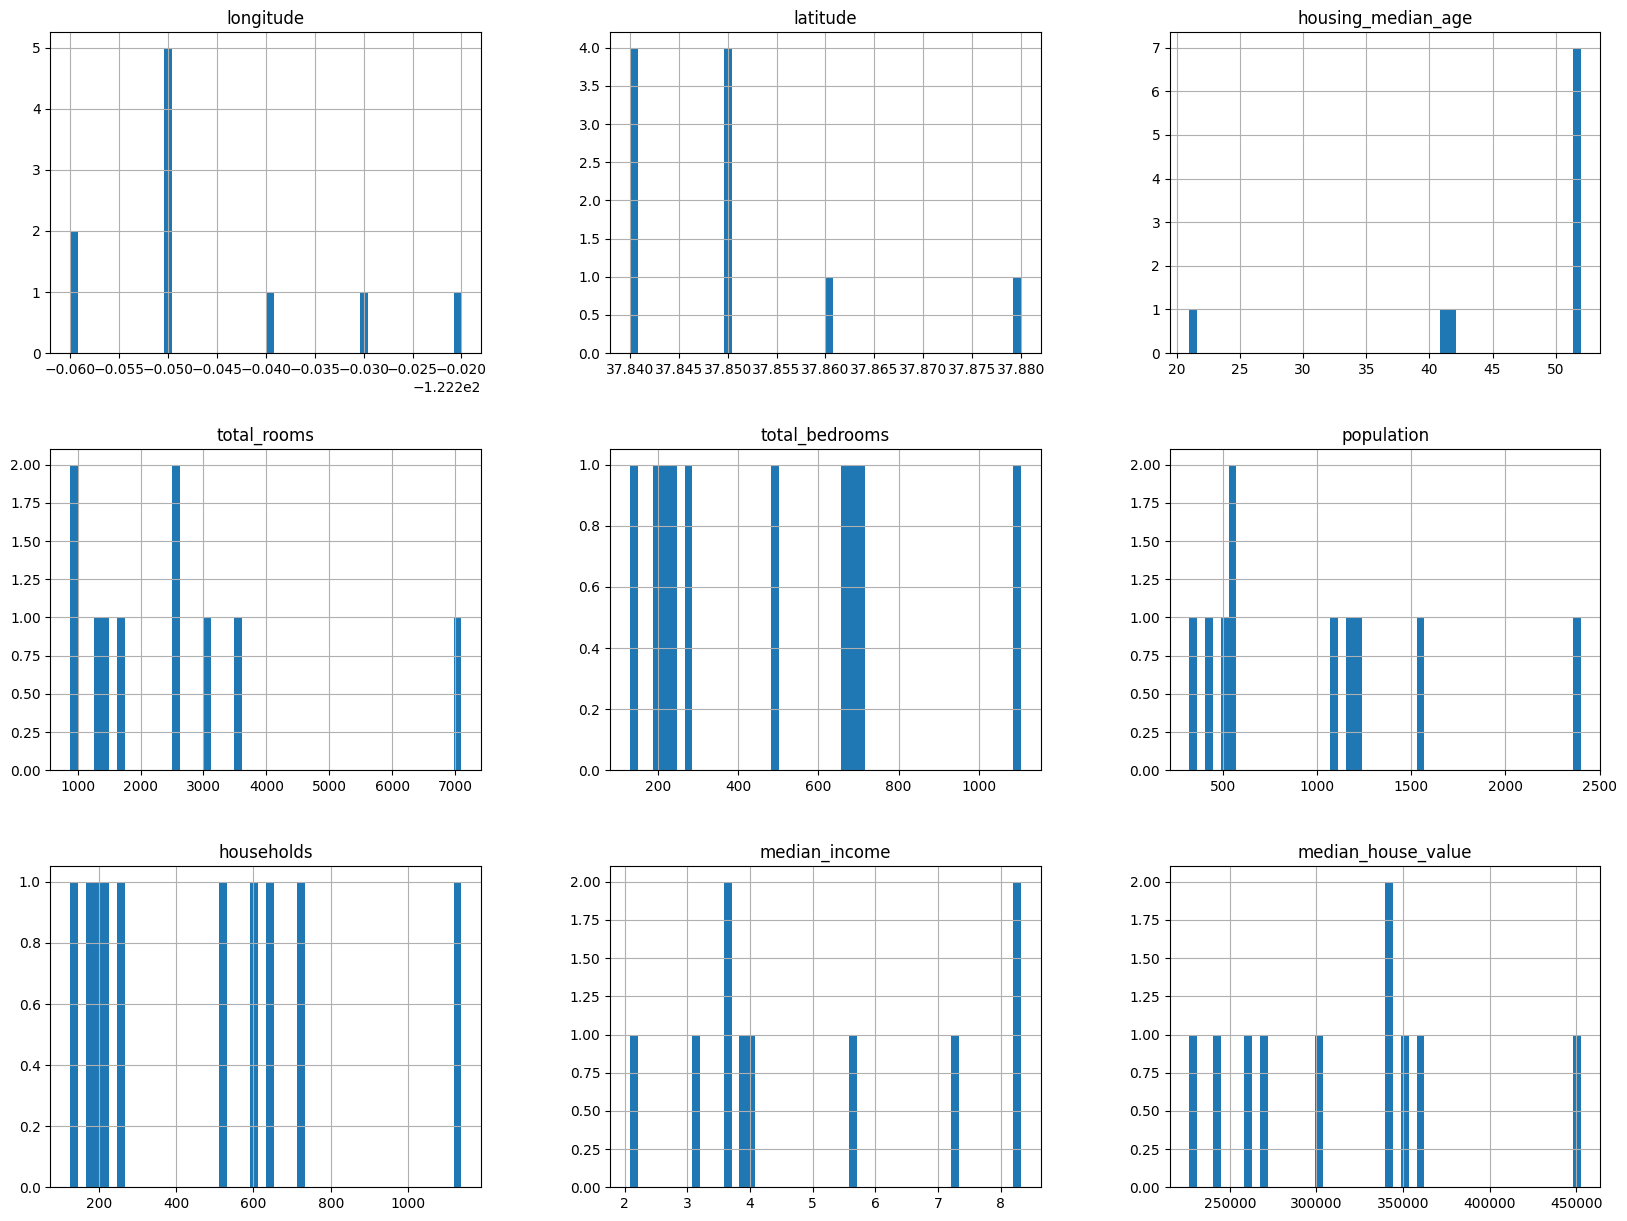

In [2]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split

housing = pd.read_csv("housing.csv")

import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [7]:
import hashlib
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split

# Carrega o dataset
housing = pd.read_csv("housing.csv")

# Função simples de divisão aleatória em treino e teste
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

# Aplica divisão aleatória
train_set, test_set = split_train_test(housing, 0.2)
print(len(train_set), "train +", len(test_set), "test")

# Função para verificar se uma amostra deve estar no conjunto de teste com base em hash
def test_set_check(identifier, test_ratio, hash):
    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio 

# Função de divisão baseada em identificador (para resultados reprodutíveis)
def split_train_test_by_id(data, test_ratio, id_column, hash=hashlib.md5):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio, hash))
    return data.loc[~in_test_set], data.loc[in_test_set]

# Adiciona uma coluna 'index' como identificador único
housing_with_id = housing.reset_index()  # adiciona uma coluna 'index'

# Aplica divisão usando identificador
train_set_id, test_set_id = split_train_test_by_id(housing_with_id, 0.2, "index")
print(len(train_set_id), "train ID-based +", len(test_set_id), "test ID-based")

8 train + 2 test
8 train ID-based + 2 test ID-based


In [10]:
import hashlib
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split

# Carrega o dataset
housing = pd.read_csv("housing.csv")

# Adiciona uma coluna de ID
housing_with_id = housing.reset_index()
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]

# Split aleatório
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

# Cria a coluna de categoria de renda
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
housing["income_cat"] = housing["income_cat"].where(housing["income_cat"] < 5, 5.0)
print(housing["income_cat"])

0    5.0
1    5.0
2    5.0
3    4.0
4    3.0
5    3.0
6    3.0
7    3.0
8    2.0
9    3.0
Name: income_cat, dtype: float64


In [13]:
import hashlib
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split

# Carrega o dataset
housing = pd.read_csv("housing.csv")

# Adiciona uma coluna de ID
housing_with_id = housing.reset_index()
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]

# Split aleatório
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

# Cria a coluna de categoria de renda
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
housing["income_cat"] = housing["income_cat"].where(housing["income_cat"] < 5, 5.0)
print(housing["income_cat"])

from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42) 
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

strat_test_set["income_cat"].value_counts() 

0    5.0
1    5.0
2    5.0
3    4.0
4    3.0
5    3.0
6    3.0
7    3.0
8    2.0
9    3.0
Name: income_cat, dtype: float64


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.